# AdsorbML Results — ranked_candidates.csv Analysis
ML-predicted H adsorption energies on Mo-based surfaces.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.15)
PALETTE = sns.color_palette('tab10')
plt.rcParams['figure.dpi'] = 120

VIZDIR = Path('data/visualizations')
VIZDIR.mkdir(parents=True, exist_ok=True)

## 1. Load & Feature Engineering

In [ ]:
CSV = Path('data/adsorbml_results/ranked_candidates_stable_filtered.csv')
df = pd.read_csv(CSV)

def parse_slab(name):
    if name.startswith('Ni_'):
        substrate = re.match(r'^Ni_([A-Za-z0-9]+)_interface', name)
        material = f'Ni/{substrate.group(1)}' if substrate else 'Ni_interface'
    else:
        mat_match = re.match(r'^([A-Za-z0-9]+)_', name)
        material = mat_match.group(1) if mat_match else 'Other'

    facet_match = re.search(r'\((\d+)\)', name)
    facet = facet_match.group(1) if facet_match else 'unknown'

    if re.search(r'_dop([A-Z][a-z]?)', name):
        mod = 'dopant'
        dopant = re.search(r'_dop([A-Z][a-z]?)', name).group(1)
    elif re.search(r'_vac', name):
        mod = 'vacancy'
        dopant = None
    elif '_sheet' in name:
        mod = 'sheet'
        dopant = None
    elif '_cluster' in name:
        mod = 'cluster'
        cl = re.search(r'_cluster\d+([A-Z][a-z]?)', name)
        dopant = cl.group(1) if cl else None
    else:
        mod = 'pristine'
        dopant = None

    return pd.Series({'material': material, 'facet': facet, 'modification': mod, 'dopant': dopant})

df[['material', 'facet', 'modification', 'dopant']] = df['slab_name'].apply(parse_slab)

df = df[df['E_ads_ml_eV'] <= 1.0].copy()

# material colour palette — defined here so all downstream cells can use it
mat_cats = sorted(df['material'].unique())
pal = dict(zip(mat_cats, sns.color_palette('tab10', len(mat_cats))))

print(f'Rows after filtering: {len(df)}')
print(f'Material families: {mat_cats}')
df[['slab_name', 'E_ads_ml_eV', 'gibbs_free_ml_eV', 'Fmax_slab_eV_per_Ang',
    'material', 'facet', 'modification']].describe()

Rows after filtering: 255
Material families: ['Mo2C', 'Mo2N', 'MoB', 'MoP', 'MoS2', 'MoSe2', 'Ni/Mo2C', 'Ni/Mo2N', 'Ni/MoS2', 'Ni/Ti3C2O2', 'Ti3C2O2']


,E_ads_ml_eV,gibbs_free_ml_eV,Fmax_slab_eV_per_Ang
count,255.000000,255.000000,254.000000
mean,-1.033990,-0.793990,1.317128
std,0.822510,0.822510,8.930286
min,-2.484468,-2.244468,0.000937
25%,-1.761805,-1.521805,0.018952
50%,-0.874222,-0.634222,0.162863
75%,-0.480870,-0.240870,0.572491
max,0.957434,1.197434,114.598770


## 2. Top 20 Candidates Table (ranked by |ΔG_H| closest to zero)

In [3]:
top20 = (
    df.assign(abs_gibbs=df['gibbs_free_ml_eV'].abs())
    .nsmallest(20, 'abs_gibbs')
    .drop(columns='abs_gibbs')
    [['slab_name', 'gibbs_free_ml_eV', 'E_ads_ml_eV', 'Fmax_slab_eV_per_Ang', 'material', 'facet', 'modification']]
    .reset_index(drop=True)
)
top20.index += 1
top20.style.format({'gibbs_free_ml_eV': '{:.4f}', 'E_ads_ml_eV': '{:.4f}', 'Fmax_slab_eV_per_Ang': '{:.4f}'})

,slab_name,gibbs_free_ml_eV,E_ads_ml_eV,Fmax_slab_eV_per_Ang,material,facet,modification
1,Mo2C_(100)_dopAu,-0.0004,-0.2404,1.5990,Mo2C,100,dopant
2,MoB_(110)_dopAg,-0.0032,-0.2432,0.4639,MoB,110,dopant
3,Ni_MoS2_interface_(100)_cluster4Pt,0.0088,-0.2312,0.0180,Ni/MoS2,100,cluster
4,Mo2N_(100)_vacMo,0.0101,-0.2299,3.5473,Mo2N,100,vacancy
5,Mo2N_(111)_dopRu,-0.0196,-0.2596,0.3704,Mo2N,111,dopant
6,Mo2C_(110)_vac2Mo,0.0197,-0.2203,0.6778,Mo2C,110,vacancy
7,MoB_(111)_dopRu,-0.0428,-0.2828,0.5762,MoB,111,dopant
8,Mo2N_(111)_vacN,-0.0468,-0.2868,0.0097,Mo2N,111,vacancy
9,Mo2N_(111)_vac2N,-0.0478,-0.2878,0.0111,Mo2N,111,vacancy
10,Mo2N_(111),-0.0482,-0.2882,0.0128,Mo2N,111,pristine


## 3. Fmax_slab vs E_ads — Correlation (requested)

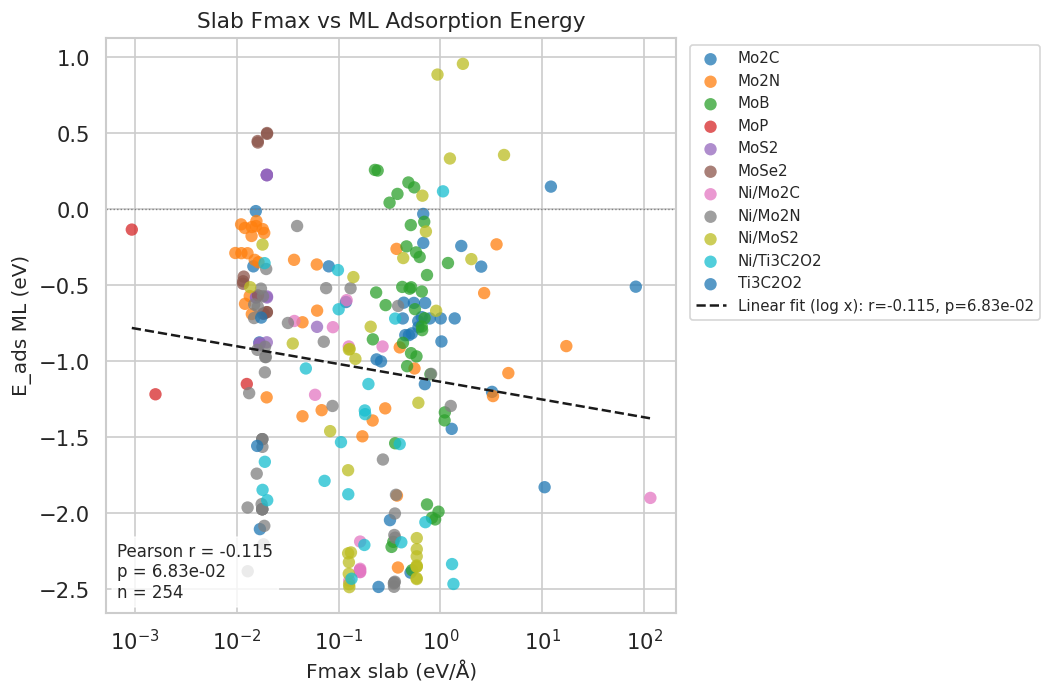

In [4]:
sub = df.dropna(subset=['Fmax_slab_eV_per_Ang', 'E_ads_ml_eV'])
sub = sub[sub['Fmax_slab_eV_per_Ang'] > 0]

slope, intercept, r, p, _ = stats.linregress(np.log10(sub['Fmax_slab_eV_per_Ang']), sub['E_ads_ml_eV'])

fig, ax = plt.subplots(figsize=(9, 6))

for mat, grp in sub.groupby('material'):
    ax.scatter(grp['Fmax_slab_eV_per_Ang'], grp['E_ads_ml_eV'],
               color=pal[mat], label=mat, alpha=0.75, edgecolors='none', s=55)

# regression line in log-x space
x_fit = np.logspace(np.log10(sub['Fmax_slab_eV_per_Ang'].min()),
                    np.log10(sub['Fmax_slab_eV_per_Ang'].max()), 200)
y_fit = slope * np.log10(x_fit) + intercept
ax.plot(x_fit, y_fit, 'k--', lw=1.5, label=f'Linear fit (log x): r={r:.3f}, p={p:.2e}')

ax.set_xscale('log')
ax.set_xlabel('Fmax slab (eV/Å)', fontsize=12)
ax.set_ylabel('E_ads ML (eV)', fontsize=12)
ax.set_title('Slab Fmax vs ML Adsorption Energy', fontsize=13)
ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.text(0.02, 0.02, f'Pearson r = {r:.3f}\np = {p:.2e}\nn = {len(sub)}',
        transform=ax.transAxes, va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig(VIZDIR / 'fmax_vs_eads.png', bbox_inches='tight')
plt.show()

## 4. E_ads Distribution

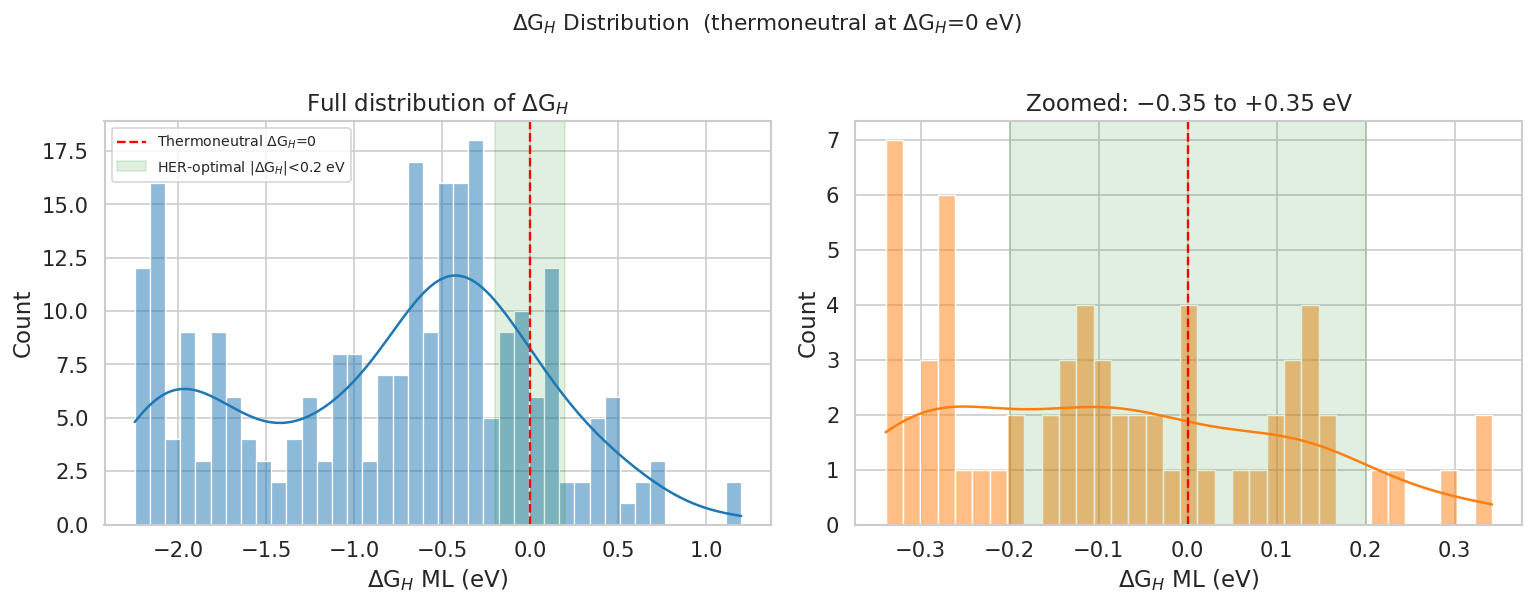

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

DGH_NEUTRAL = 0.0
DGH_OPT_LO, DGH_OPT_HI = -0.2, 0.2

ax = axes[0]
sns.histplot(df['gibbs_free_ml_eV'], bins=40, kde=True, ax=ax, color=PALETTE[0])
ax.axvline(DGH_NEUTRAL, color='red', lw=1.4, ls='--',
           label='Thermoneutral ΔG$_H$=0')
ax.axvspan(DGH_OPT_LO, DGH_OPT_HI, alpha=0.12, color='green',
           label='HER-optimal |ΔG$_H$|<0.2 eV')
ax.set_xlabel('ΔG$_H$ ML (eV)')
ax.set_title('Full distribution of ΔG$_H$')
ax.legend(fontsize=8.5)

ax2 = axes[1]
zoom = df[df['gibbs_free_ml_eV'].between(-0.35, 0.35)]
sns.histplot(zoom['gibbs_free_ml_eV'], bins=35, kde=True, ax=ax2, color=PALETTE[1])
ax2.axvline(DGH_NEUTRAL, color='red', lw=1.4, ls='--')
ax2.axvspan(DGH_OPT_LO, DGH_OPT_HI, alpha=0.12, color='green')
ax2.set_xlabel('ΔG$_H$ ML (eV)')
ax2.set_title('Zoomed: −0.35 to +0.35 eV')

plt.suptitle('ΔG$_H$ Distribution  (thermoneutral at ΔG$_H$=0 eV)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(VIZDIR / 'dgh_distribution.png', bbox_inches='tight')
plt.show()

## 6. Per-Material Box Plot

/tmp/ipykernel_1441188/3598068429.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='material', y='gibbs_free_ml_eV', order=mat_order,
/tmp/ipykernel_1441188/3598068429.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{m}({mat_counts[m]})' for m in mat_order])


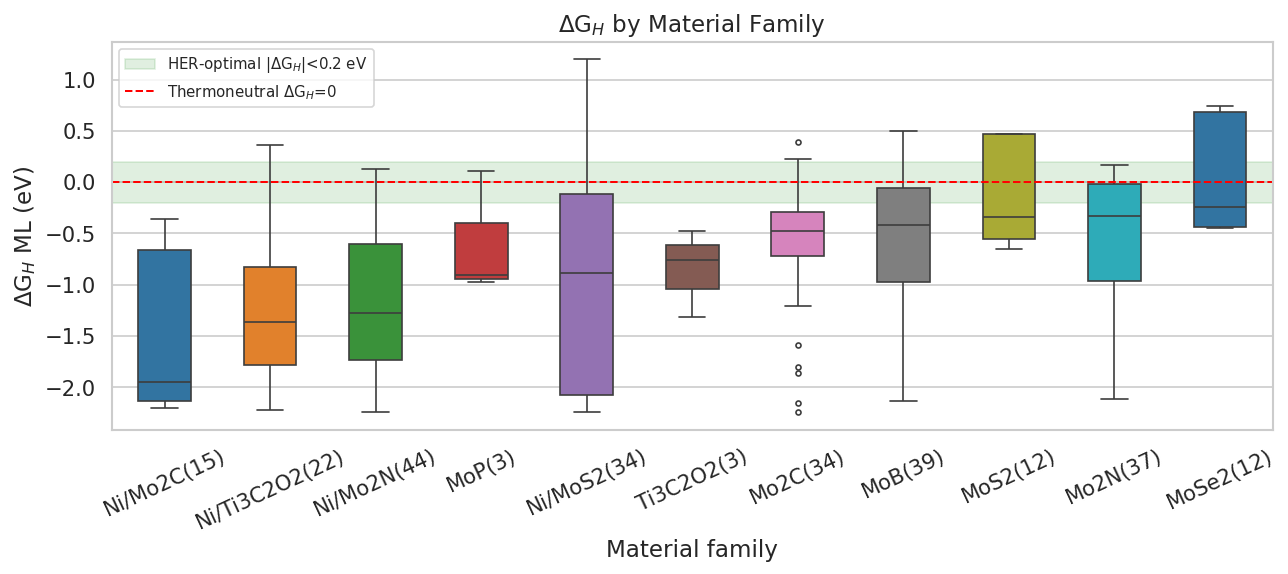

In [6]:
mat_order = (
    df.groupby('material')['gibbs_free_ml_eV'].median()
    .sort_values().index.tolist()
)
mat_counts = df.groupby('material').size()

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='material', y='gibbs_free_ml_eV', order=mat_order,
            palette='tab10', ax=ax, width=0.5, fliersize=3)
ax.axhspan(-0.2, 0.2, alpha=0.12, color='green',
           label='HER-optimal |ΔG$_H$|<0.2 eV')
ax.axhline(0, color='red', lw=1.2, ls='--',
           label='Thermoneutral ΔG$_H$=0')
ax.set_xticklabels([f'{m}({mat_counts[m]})' for m in mat_order])
ax.set_xlabel('Material family')
ax.set_ylabel('ΔG$_H$ ML (eV)')
ax.set_title('ΔG$_H$ by Material Family')
ax.tick_params(axis='x', rotation=25)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(VIZDIR / 'dgh_by_material.png', bbox_inches='tight')
plt.show()

## 7. Per-Facet Violin Plot

/tmp/ipykernel_1441188/4288463824.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=facet_df, x='facet', y='E_ads_ml_eV',


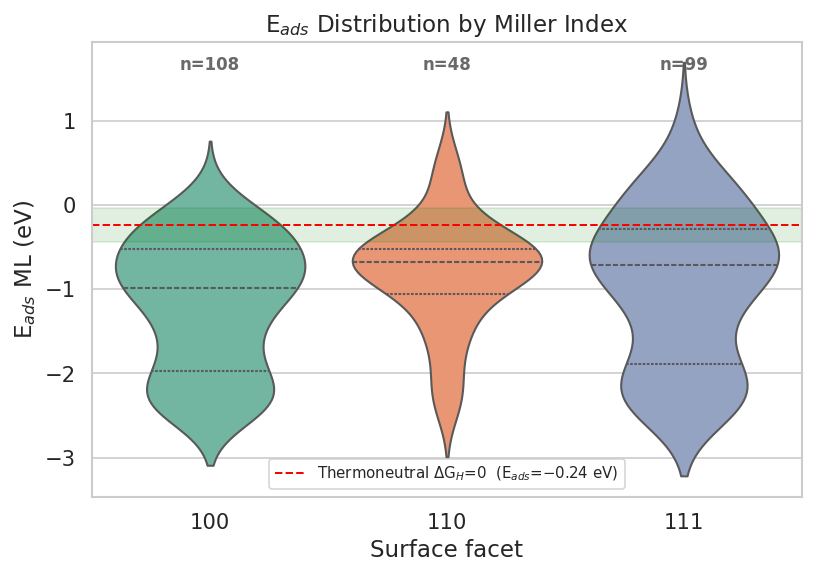

In [7]:
facet_df = df[df['facet'].isin(['100', '110', '111'])]
facet_counts = facet_df.groupby('facet').size()

fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=facet_df, x='facet', y='E_ads_ml_eV',
               order=['100', '110', '111'], palette='Set2', inner='quartile', ax=ax)
ax.axhspan(-0.44, -0.04, alpha=0.12, color='green')
ax.axhline(-0.24, color='red', lw=1.2, ls='--',
           label='Thermoneutral ΔG$_H$=0  (E$_{ads}$=−0.24 eV)')

# n= annotation at the top of each violin
ylim = ax.get_ylim()
top_y = ylim[1] - 0.03 * (ylim[1] - ylim[0])
for i, facet in enumerate(['100', '110', '111']):
    n = facet_counts.get(facet, 0)
    ax.text(i, top_y, f'n={n}', ha='center', va='top',
            fontsize=10, color='dimgrey', fontweight='bold')

ax.set_xlabel('Surface facet')
ax.set_ylabel('E$_{ads}$ ML (eV)')
ax.set_title('E$_{ads}$ Distribution by Miller Index')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(VIZDIR / 'eads_by_facet.png', bbox_inches='tight')
plt.show()

## 8. Top 25 Candidates — Horizontal Bar Chart (ranked by |ΔG_H| closest to zero)

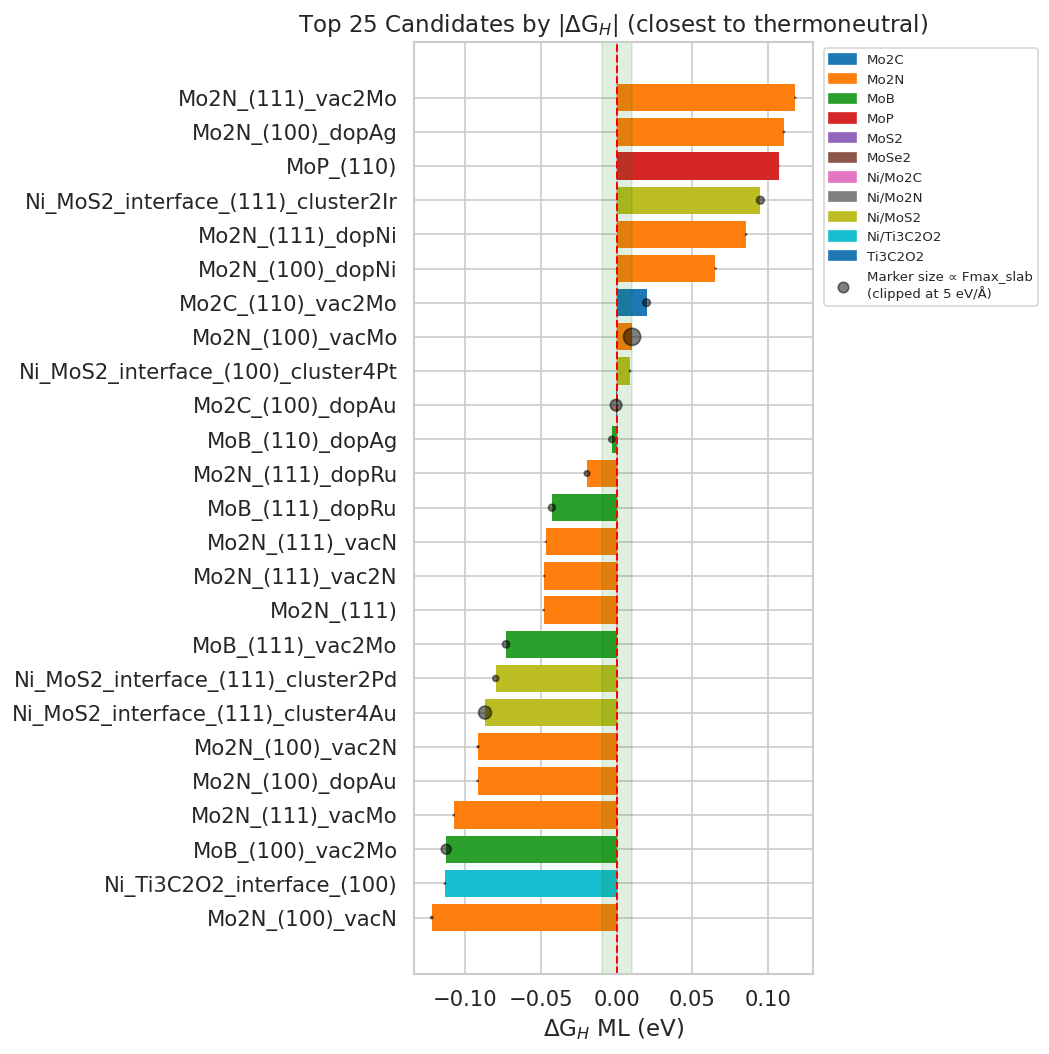

In [8]:
top25 = (
    df.assign(abs_gibbs=df['gibbs_free_ml_eV'].abs())
    .nsmallest(25, 'abs_gibbs')
    .sort_values('gibbs_free_ml_eV')
)
colors = [pal.get(m, 'grey') for m in top25['material']]

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(top25['slab_name'], top25['gibbs_free_ml_eV'], color=colors, edgecolor='none')

# Fmax as marker size (clipped at 5 eV/Å to prevent oversized markers)
fmax_norm = np.clip(top25['Fmax_slab_eV_per_Ang'].fillna(0), 0, 5)
ax.scatter(top25['gibbs_free_ml_eV'], top25['slab_name'],
           s=fmax_norm * 30, color='black', alpha=0.5, zorder=5,
           label='Marker size ∝ Fmax_slab (clipped at 5 eV/Å)')

ax.axvline(0, color='red', lw=1.2, ls='--', label='Thermoneutral')
ax.axvspan(-0.01, 0.01, alpha=0.12, color='green', label='HER-optimal window')
ax.set_xlabel('ΔG$_H$ ML (eV)')
ax.set_title('Top 25 Candidates by |ΔG$_H$| (closest to thermoneutral)')

handles = [mpatches.Patch(color=pal[m], label=m) for m in mat_cats if m in pal]
handles += [plt.scatter([], [], s=40, color='black', alpha=0.5,
                        label='Marker size ∝ Fmax_slab\n(clipped at 5 eV/Å)')]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(VIZDIR / 'top25_candidates.png', bbox_inches='tight')
plt.show()

## 11. Dopant Effect Analysis — Δ|ΔG_H| vs Pristine Baseline

95 / 96 dopant slabs matched to a pristine baseline
No pristine found for: ['Mo2N_(111)_dopPt_Node1']


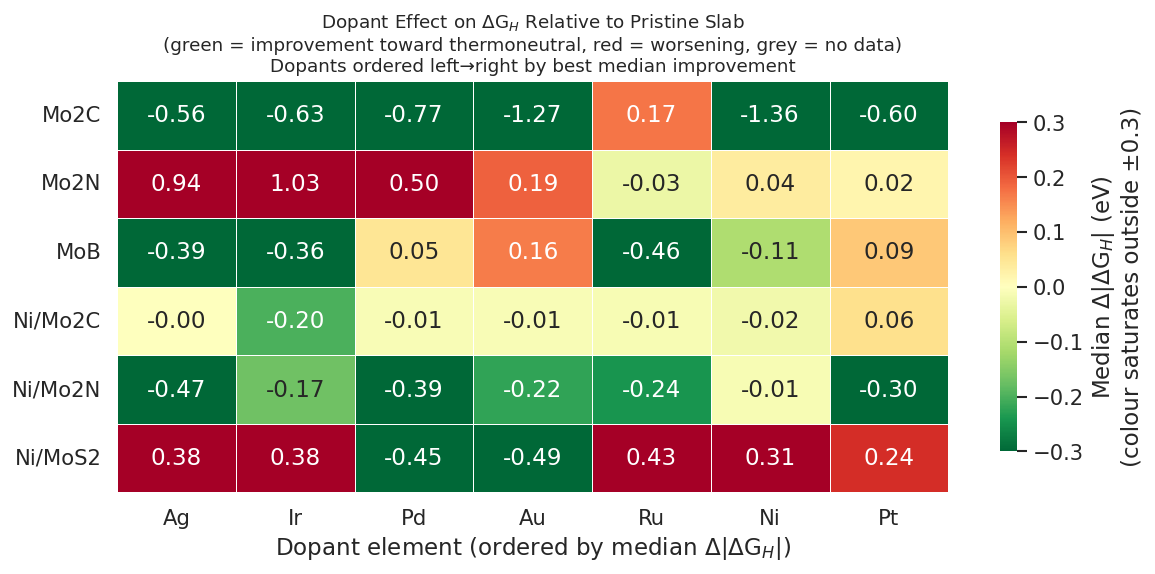

In [9]:
def get_base_slab(name):
    """Strip modification suffix to recover the pristine slab name."""
    name = re.sub(r'_dop[A-Z][a-z]?$', '', name)
    name = re.sub(r'_vac.*$', '', name)
    name = re.sub(r'_cluster\d+[A-Z][a-z]?.*$', '', name)
    name = re.sub(r'_sheet.*$', '', name)
    return name

pristine_map = df[df['modification'] == 'pristine'].set_index('slab_name')['gibbs_free_ml_eV']

doped = df[df['modification'] == 'dopant'].copy()
doped['base_slab'] = doped['slab_name'].apply(get_base_slab)
doped['gibbs_pristine'] = doped['base_slab'].map(pristine_map)

unmatched = doped.loc[doped['gibbs_pristine'].isna(), 'base_slab'].unique()
doped = doped.dropna(subset=['gibbs_pristine'])

print(f'{len(doped)} / {(df["modification"]=="dopant").sum()} dopant slabs matched to a pristine baseline')
if len(unmatched):
    print(f'No pristine found for: {list(unmatched)}')

# Improvement metric: negative → dopant moves ΔGH closer to thermoneutral → better for HER
doped['delta_abs_gibbs'] = doped['gibbs_free_ml_eV'].abs() - doped['gibbs_pristine'].abs()

dopant_order = (
    doped.groupby('dopant')['delta_abs_gibbs'].median()
    .sort_values().index.tolist()
)

pivot = (
    doped.groupby(['material', 'dopant'])['delta_abs_gibbs']
    .median().unstack()
    .reindex(columns=dopant_order)
)
annot_str = pivot.apply(lambda col: col.map(lambda v: f'{v:.2f}' if pd.notna(v) else ''))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=annot_str, fmt='', cmap='RdYlGn_r', center=0,
            vmin=-0.3, vmax=0.3, linewidths=0.5, ax=ax, mask=pivot.isna(),
            cbar_kws={'label': 'Median Δ|ΔG$_H$| (eV)\n(colour saturates outside ±0.3)',
                      'shrink': 0.8})
ax.set_title('Dopant Effect on ΔG$_H$ Relative to Pristine Slab\n'
             '(green = improvement toward thermoneutral, red = worsening, grey = no data)\n'
             'Dopants ordered left→right by best median improvement',
             fontsize=11)
ax.set_xlabel('Dopant element (ordered by median Δ|ΔG$_H$|)')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(VIZDIR / 'dopant_analysis.png', bbox_inches='tight')
plt.show()

## 12. Vacancy Effect Analysis — Δ|ΔG_H| vs Pristine Baseline

46 / 46 vacancy slabs matched to a pristine baseline


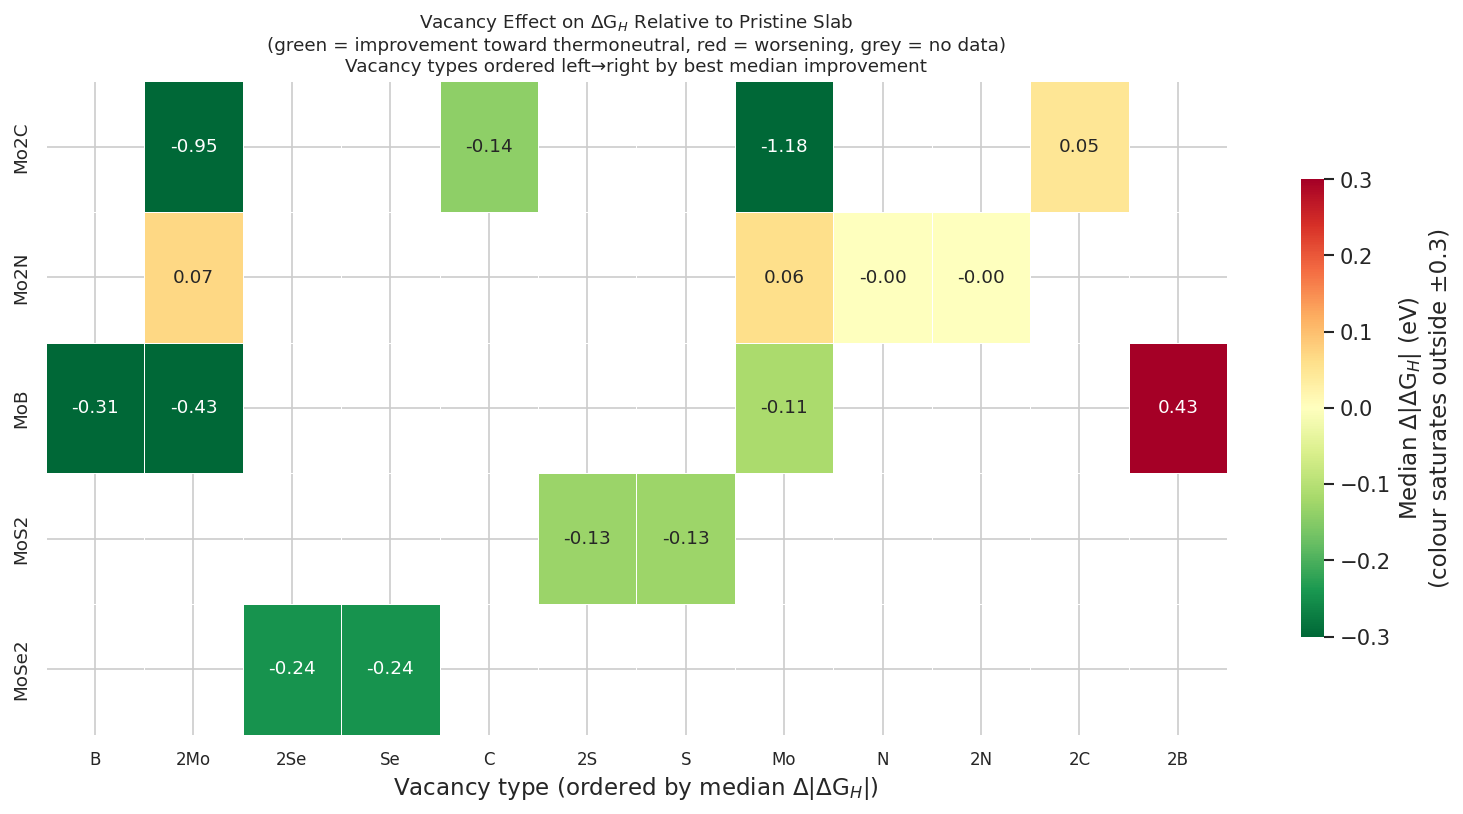

In [10]:
def get_base_slab_vac(name):
    return re.sub(r'_vac.*$', '', name)

def get_vac_type(name):
    m = re.search(r'_vac(\w+)', name)
    return m.group(1) if m else None

pristine_map_vac = df[df['modification'] == 'pristine'].set_index('slab_name')['gibbs_free_ml_eV']

vac_df = df[df['modification'] == 'vacancy'].copy()
vac_df['base_slab'] = vac_df['slab_name'].apply(get_base_slab_vac)
vac_df['vac_type'] = vac_df['slab_name'].apply(get_vac_type)
vac_df['gibbs_pristine'] = vac_df['base_slab'].map(pristine_map_vac)

unmatched = vac_df.loc[vac_df['gibbs_pristine'].isna(), 'base_slab'].unique()
vac_df = vac_df.dropna(subset=['gibbs_pristine', 'vac_type'])

print(f'{len(vac_df)} / {(df["modification"]=="vacancy").sum()} vacancy slabs matched to a pristine baseline')
if len(unmatched):
    print(f'No pristine found for: {list(unmatched)}')

vac_df['delta_abs_gibbs'] = vac_df['gibbs_free_ml_eV'].abs() - vac_df['gibbs_pristine'].abs()

vac_type_order = (
    vac_df.groupby('vac_type')['delta_abs_gibbs'].median()
    .sort_values().index.tolist()
)

pivot_vac = (
    vac_df.groupby(['material', 'vac_type'])['delta_abs_gibbs']
    .median().unstack()
    .reindex(columns=vac_type_order)
)
annot_str_vac = pivot_vac.apply(lambda col: col.map(lambda v: f'{v:.2f}' if pd.notna(v) else ''))

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot_vac, annot=annot_str_vac, fmt='', cmap='RdYlGn_r', center=0,
            vmin=-0.3, vmax=0.3, linewidths=0.5, ax=ax, mask=pivot_vac.isna(),
            annot_kws={'size': 11},
            cbar_kws={'label': 'Median Δ|ΔG$_H$| (eV)\n(colour saturates outside ±0.3)',
                      'shrink': 0.7})
ax.set_title('Vacancy Effect on ΔG$_H$ Relative to Pristine Slab\n'
             '(green = improvement toward thermoneutral, red = worsening, grey = no data)\n'
             'Vacancy types ordered left→right by best median improvement',
             fontsize=11)
ax.set_xlabel('Vacancy type (ordered by median Δ|ΔG$_H$|)')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig(VIZDIR / 'vacancy_analysis.png', bbox_inches='tight')
plt.show()

## 12. Volcano Plots — Per Material Family

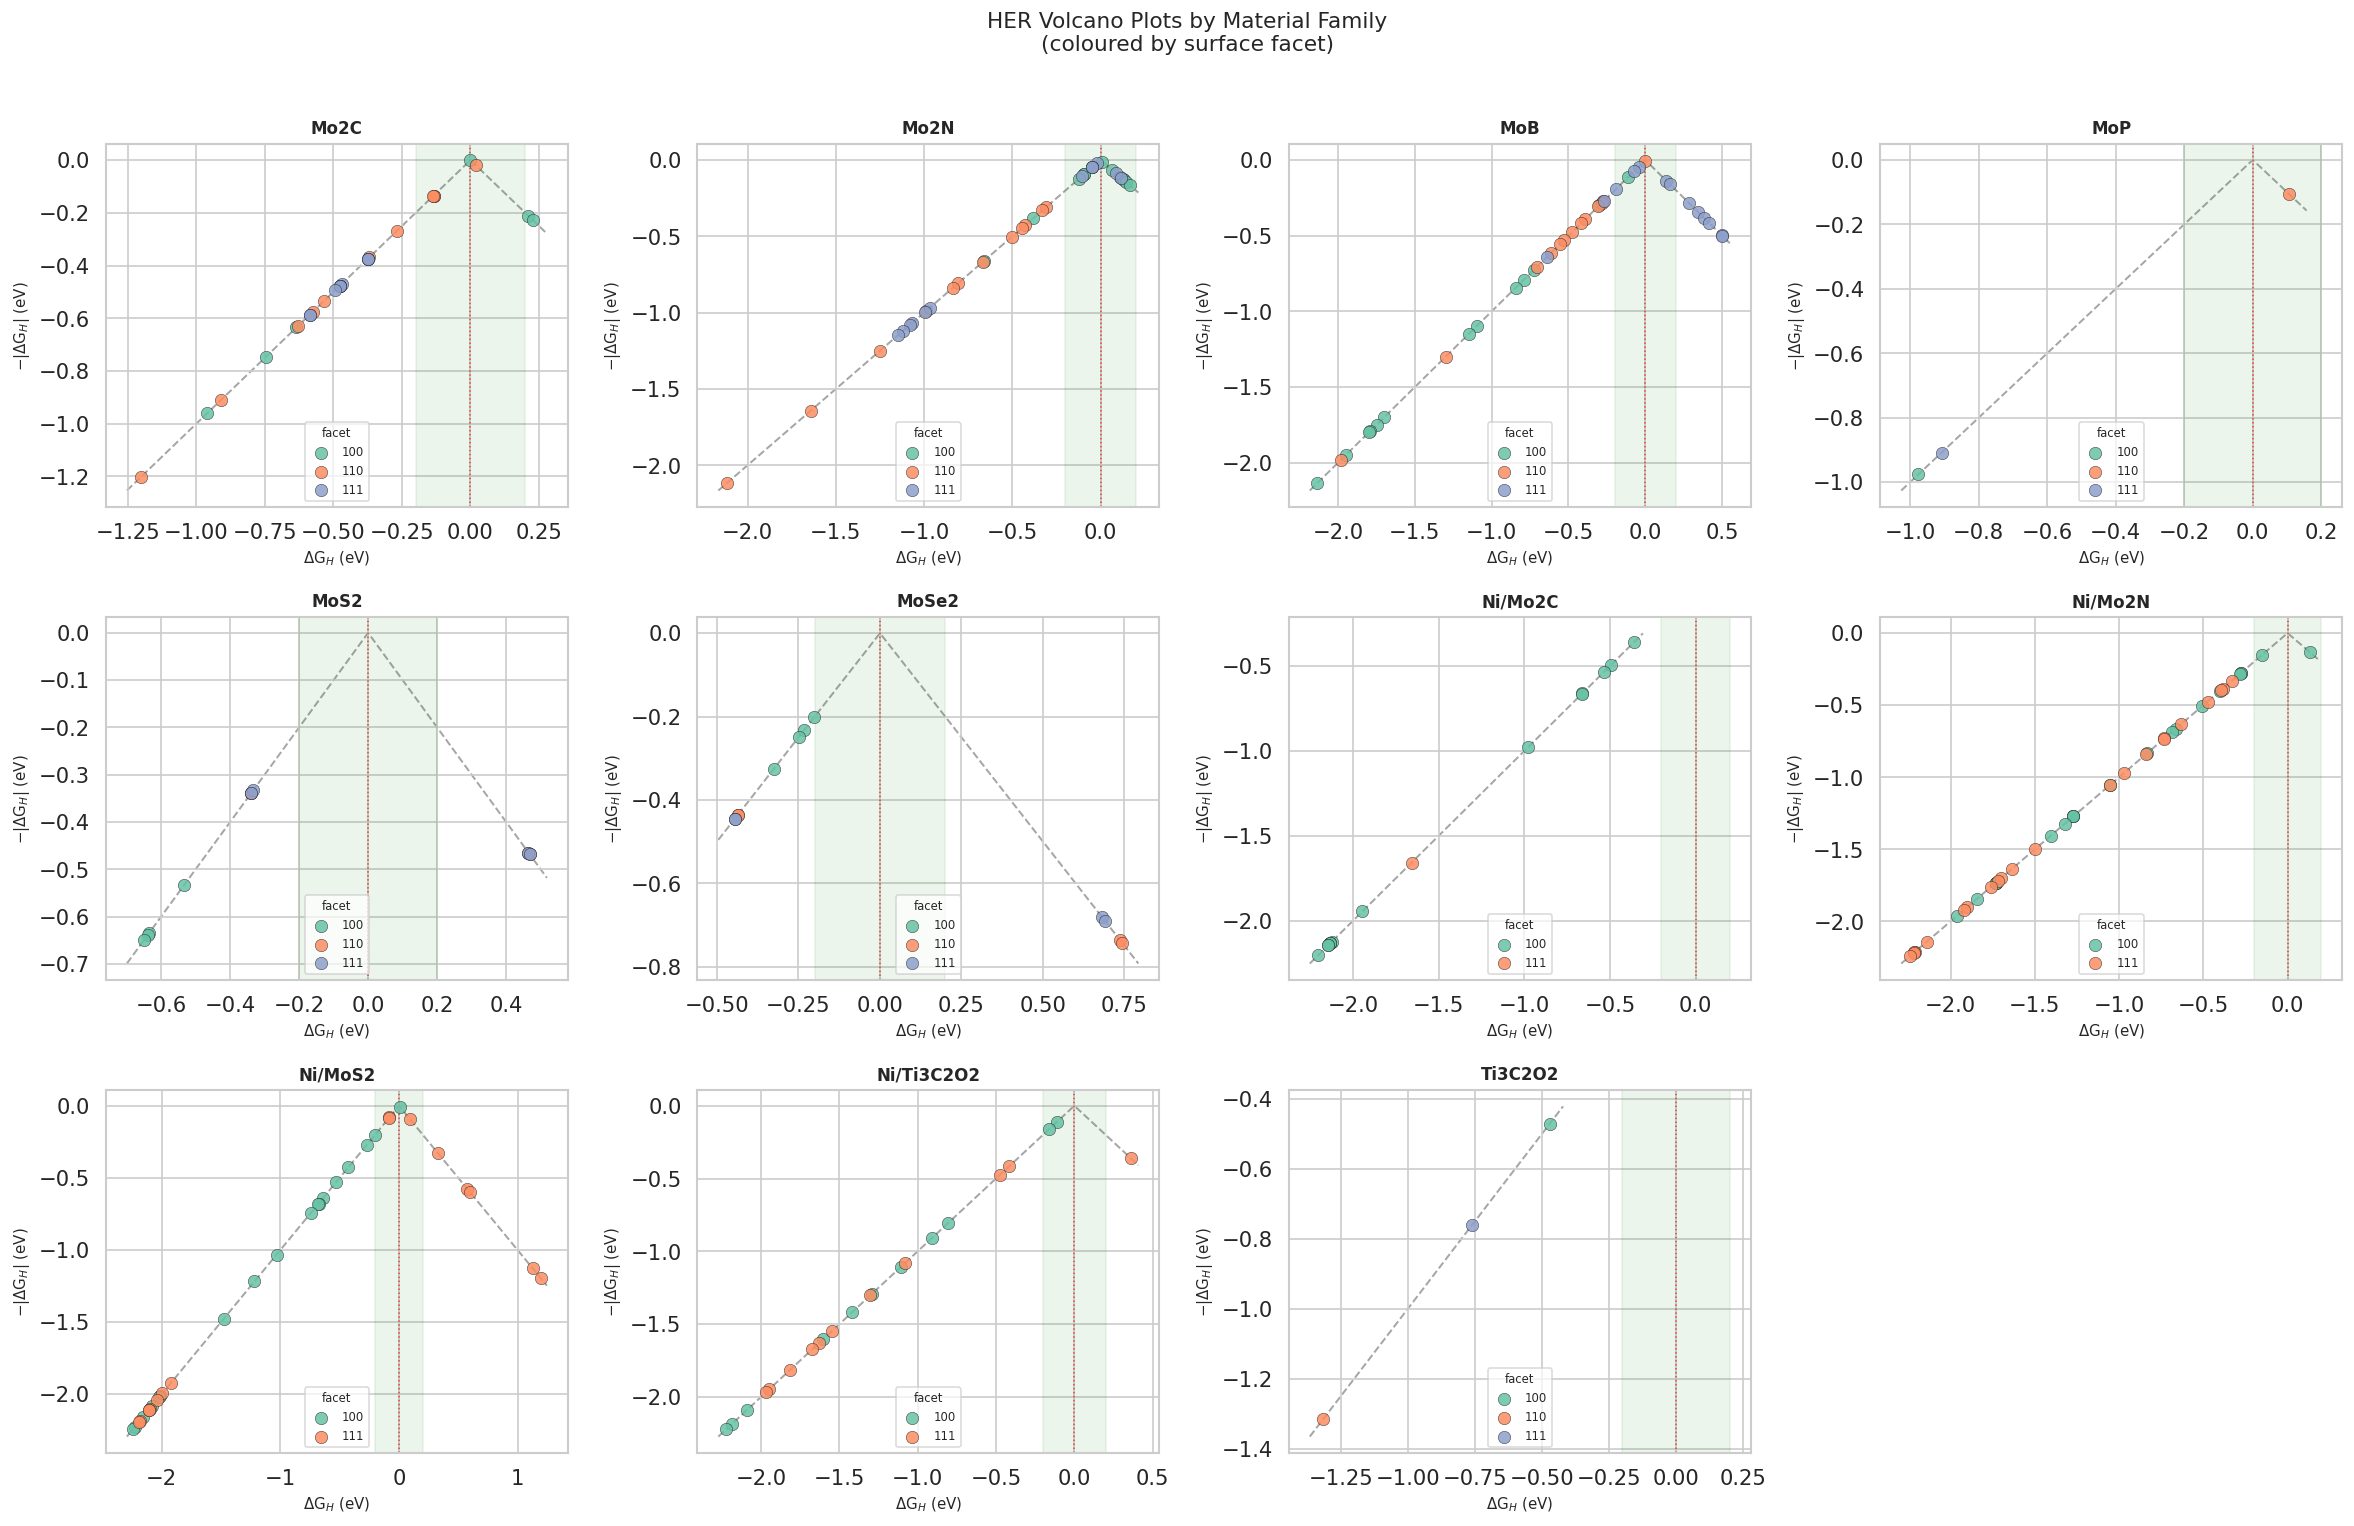

In [11]:
def remove_outliers(sub, col='gibbs_free_ml_eV', iqr_factor=1.5):
    Q1, Q3 = sub[col].quantile(0.25), sub[col].quantile(0.75)
    IQR = Q3 - Q1
    return sub[(sub[col] >= Q1 - iqr_factor * IQR) & (sub[col] <= Q3 + iqr_factor * IQR)]


def plot_volcano(ax, sub, hue_col='facet', title='', label_points=False):
    """Scatter volcano: X = ΔG_H, Y = −|ΔG_H| (theoretical activity)."""
    sub = sub.copy()
    sub['activity'] = -sub['gibbs_free_ml_eV'].abs()

    # volcano envelope (two-branch guide line)
    x_env = np.linspace(sub['gibbs_free_ml_eV'].min() - 0.05,
                        sub['gibbs_free_ml_eV'].max() + 0.05, 300)
    ax.plot(x_env, -np.abs(x_env), color='black', lw=1.2, ls='--', alpha=0.35, zorder=0)

    cats = sorted(sub[hue_col].dropna().unique())
    pal_local = dict(zip(cats, sns.color_palette('Set2', len(cats))))

    for cat, grp in sub.groupby(hue_col):
        ax.scatter(grp['gibbs_free_ml_eV'], grp['activity'],
                   color=pal_local[cat], label=str(cat),
                   s=55, alpha=0.85, edgecolors='k', linewidths=0.3, zorder=3)

    if label_points:
        for _, row in sub.iterrows():
            ax.annotate(row['slab_name'], (row['gibbs_free_ml_eV'], row['activity']),
                        fontsize=6.5, ha='left', va='bottom',
                        xytext=(3, 3), textcoords='offset points', alpha=0.8)

    ax.axvline(0, color='red', lw=0.9, ls=':', alpha=0.7)
    ax.axvspan(-0.2, 0.2, alpha=0.08, color='green')
    ax.set_xlabel('ΔG$_H$ (eV)', fontsize=9)
    ax.set_ylabel('−|ΔG$_H$| (eV)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(title=hue_col, fontsize=7, title_fontsize=7,
              loc='lower center', framealpha=0.7)


families = sorted(df['material'].unique())
ncols = 4
nrows = -(-len(families) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.2), sharey=False)
axes = axes.flatten()

for i, family in enumerate(families):
    sub = df[df['material'] == family]
    sub = remove_outliers(sub)
    plot_volcano(axes[i], sub, hue_col='facet', title=family)

for j in range(len(families), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('HER Volcano Plots by Material Family\n(coloured by surface facet)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(VIZDIR / 'volcano_per_family.png', bbox_inches='tight')
plt.show()

## 13. Volcano Plot — Best 20 Candidates (by |ΔG_H|)

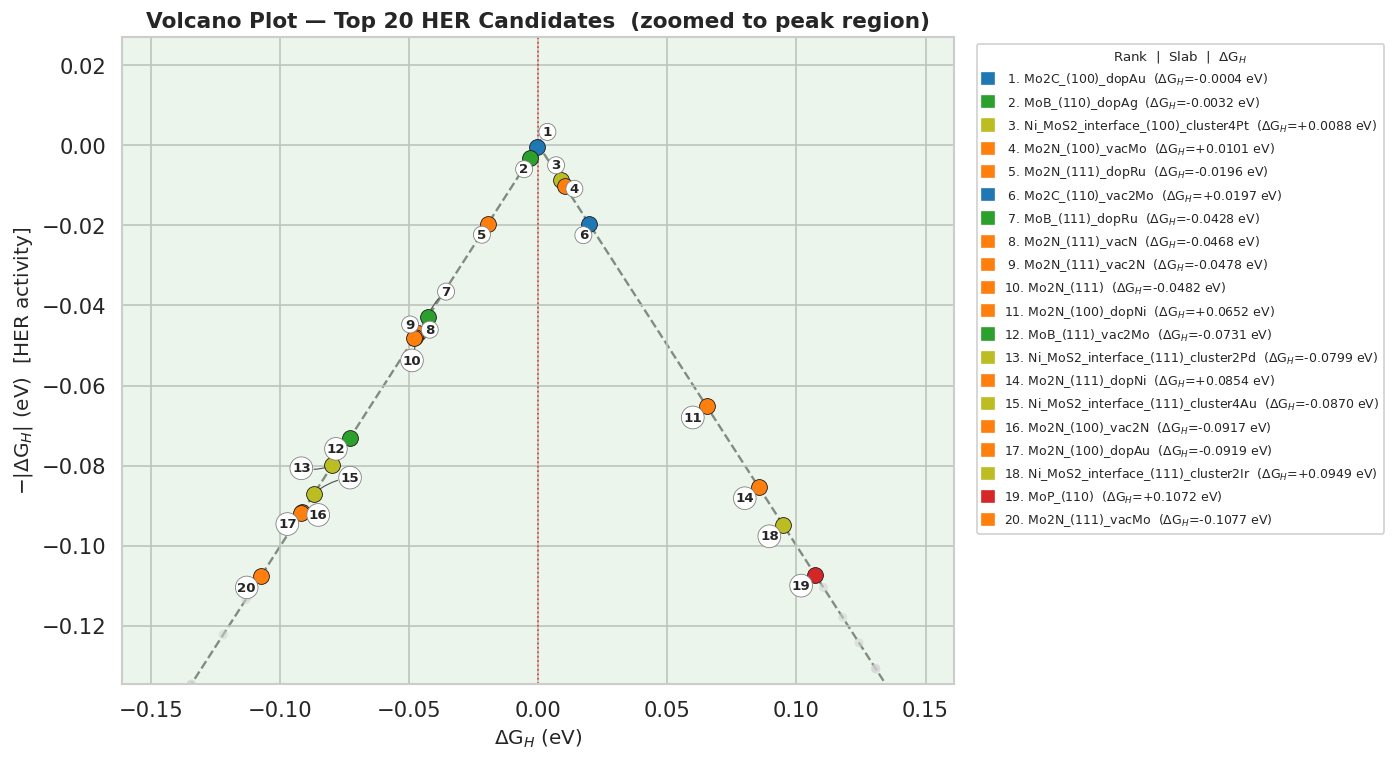

In [12]:
from adjustText import adjust_text

top20 = (
    df.assign(abs_gibbs=df['gibbs_free_ml_eV'].abs())
    .nsmallest(20, 'abs_gibbs')
    .reset_index(drop=True)
)
top20.insert(0, 'rank', range(1, 21))
top20['activity'] = -top20['gibbs_free_ml_eV'].abs()

fig, ax = plt.subplots(figsize=(14, 7))

# Zoom in on top-20 region with margin
dg = top20['gibbs_free_ml_eV']
act = top20['activity']
x_pad = max((dg.max() - dg.min()) * 0.25, 0.003)
y_pad = max(abs(act.min()) * 0.25, 0.002)
xlim = (dg.min() - x_pad, dg.max() + x_pad)
ylim = (act.min() - y_pad, abs(act.min()) * 0.25)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# Volcano envelope clipped to view
x_env = np.linspace(xlim[0], xlim[1], 300)
ax.plot(x_env, -np.abs(x_env), color='black', lw=1.4, ls='--', alpha=0.45, zorder=0,
        label='Volcano envelope')

# Reference lines
ax.axvspan(-0.2, 0.2, alpha=0.08, color='green', label='HER-optimal |ΔG$_H$|<0.2 eV')
ax.axvline(0, color='red', lw=1.0, ls=':', alpha=0.75, label='Thermoneutral (ΔG$_H$=0)')

# All 257 candidates as grey background (auto-clipped to axes)
ax.scatter(df['gibbs_free_ml_eV'], -df['gibbs_free_ml_eV'].abs(),
           color='lightgrey', s=30, alpha=0.55, edgecolors='none', zorder=1, clip_on=True)

# Top-20 colored by material
for _, row in top20.iterrows():
    ax.scatter(row['gibbs_free_ml_eV'], row['activity'],
               color=pal[row['material']], s=90,
               edgecolors='k', linewidths=0.5, zorder=4)

ax.set_xlabel('ΔG$_H$ (eV)', fontsize=12)
ax.set_ylabel('−|ΔG$_H$| (eV)  [HER activity]', fontsize=12)
ax.set_title('Volcano Plot — Top 20 HER Candidates  (zoomed to peak region)', fontsize=13, fontweight='bold')

# Reserve space for the right-side legend before laying out labels
plt.subplots_adjust(right=0.62)

# Rank labels — repelled apart with adjustText so the apex cluster stays legible
label_bbox = dict(boxstyle='circle', fc='white', ec='gray', lw=0.5, pad=0.15)
texts = [
    ax.text(row['gibbs_free_ml_eV'], row['activity'], str(row['rank']),
            fontsize=8, fontweight='bold', ha='center', va='center',
            bbox=label_bbox, zorder=5)
    for _, row in top20.iterrows()
]
adjust_text(
    texts, ax=ax,
    x=top20['gibbs_free_ml_eV'].values, y=top20['activity'].values,
    expand=(1.6, 1.8), force_text=(0.5, 0.7), force_static=(0.3, 0.4),
    arrowprops=dict(arrowstyle='->', color='#555555', lw=0.7,
                    connectionstyle='arc3,rad=0.15'),
)

# Right-side legend: numbered slab list
legend_handles = [
    mpatches.Patch(
        color=pal[row['material']],
        label=f"{row['rank']:2d}. {row['slab_name']}  (ΔG$_H$={row['gibbs_free_ml_eV']:+.4f} eV)"
    )
    for _, row in top20.iterrows()
]
ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.02, 1), loc='upper left',
    fontsize=7.5, framealpha=0.9,
    title='Rank  |  Slab  |  ΔG$_H$',
    title_fontsize=8,
    handlelength=1.0, handleheight=1.0,
)

plt.savefig(VIZDIR / 'volcano_best20.png', bbox_inches='tight', dpi=150)
plt.show()